# 03 Main Analysis

## Ziel
Dieses Notebook beantwortet die vier Leitfragen der Case Study mit einem gemeinsamen Kanton-Panel aus Gesundheitskosten, Bevölkerung und Basis-Prämien.

**Leitfragen**
1. Welche Kantone haben die höchsten Gesundheitskosten pro Kopf, und wie hat sich dieser Druck seit 2011 entwickelt?
2. In welchen Kantonen passen Prämienniveau und Gesundheitskostenbelastung zusammen und wo gibt es Auffälligkeiten?
3. Wie stark hängt die kantonale Kostenbelastung mit dem Anteil älterer Bevölkerung zusammen?
4. Welche Kantone bilden ähnliche Belastungssegmente, und wie entwickeln sich diese bis 2030?

Dafür verbindet das Notebook:
- Gesundheitskosten
- Bevölkerung und 66+ Anteil
- Basis-Prämien

Die Analyse liefert:
- vergleichbare Kennzahlen pro Kanton und Jahr
- auffällige Kantone für Kosten, Prämien und Alterung
- Cluster für Belastungssegmente
- eine einfache Projektion bis 2030


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

import plotly.io as pio
pio.renderers.default = "notebook+png"


In [2]:
ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'data' / 'processed').exists() and (candidate / 'src').exists():
        ROOT = candidate
        break

PROCESSED_DIR = ROOT / 'data' / 'processed'

COSTS_FILE = PROCESSED_DIR / 'gesundheitskosten.csv'
POP_FILE = PROCESSED_DIR / 'bevoelkerung.csv'
POP_66_FILE = PROCESSED_DIR / 'bevoelkerung_66_share.csv'
PREMIUM_FILE = PROCESSED_DIR / 'praemien_base.csv'

for path in [COSTS_FILE, POP_FILE, POP_66_FILE, PREMIUM_FILE]:
    print(path.name, path.exists())


gesundheitskosten.csv True
bevoelkerung.csv True
bevoelkerung_66_share.csv True
praemien_base.csv True


In [3]:
df_costs = pd.read_csv(COSTS_FILE)
df_population = pd.read_csv(POP_FILE)
df_population_66 = pd.read_csv(POP_66_FILE)
df_premiums = pd.read_csv(PREMIUM_FILE)

display(pd.DataFrame({
    'dataset': ['costs', 'population', 'population_66', 'premiums_base'],
    'rows': [len(df_costs), len(df_population), len(df_population_66), len(df_premiums)],
    'columns': [df_costs.shape[1], df_population.shape[1], df_population_66.shape[1], df_premiums.shape[1]],
}))


,dataset,rows,columns
0,costs,7939,10
1,population,39984,5
2,population_66,392,6
3,premiums_base,92704,9


## 1. Kanton-Mapping und Analysefenster

Die Datensätze verwenden unterschiedliche Kantonsbezeichnungen:
- Gesundheitskosten: englische BFS-Bezeichnungen
- Bevölkerung: deutsche oder mehrsprachige Bezeichnungen
- Prämien: Kantonskürzel

Deshalb wird zuerst ein gemeinsamer Kantonsschlüssel aufgebaut. Für die gemeinsame Hauptanalyse verwenden wir nur Jahre, in denen für alle drei Themen kantonale Informationen vorhanden sind.

In [4]:
df_kantone = pd.read_csv(PROCESSED_DIR / 'kantone.csv')

CANTON_NAME_TO_CODE = dict(zip(df_kantone['canton'], df_kantone['icc']))
POPULATION_NAME_TO_CODE = CANTON_NAME_TO_CODE.copy()
CODE_TO_LABEL = dict(zip(df_kantone['icc'], df_kantone['canton']))
VALID_CANTON_CODES = set(CODE_TO_LABEL)

cost_years = df_costs.loc[
    (df_costs['age'] == 'Total')
    & (df_costs['cantons'].isin(CANTON_NAME_TO_CODE)),
    'year',
]
pop_years = df_population.loc[df_population['canton'].isin(POPULATION_NAME_TO_CODE), 'year']
premium_years = df_premiums.loc[df_premiums['canton_code'].isin(VALID_CANTON_CODES), 'year']

analysis_year_start = max(cost_years.min(), pop_years.min(), premium_years.min())
analysis_year_end = min(cost_years.max(), pop_years.max(), premium_years.max())

print(f'Analysefenster: {analysis_year_start} bis {analysis_year_end}')
print(f'Kantone im Mapping: {len(CODE_TO_LABEL)}')


Analysefenster: 2011 bis 2024
Kantone im Mapping: 26


## 2. Kanton-Panel vorbereiten

In [5]:
df_costs_canton = (
    df_costs[
        (df_costs['age'] == 'Total')
        & (df_costs['cantons'].isin(CANTON_NAME_TO_CODE))
        & (df_costs['year'].between(analysis_year_start, analysis_year_end))
    ]
    [['year', 'cantons', 'costs_chf', 'cost_status_label']]
    .copy()
)
df_costs_canton['canton_code'] = df_costs_canton['cantons'].map(CANTON_NAME_TO_CODE)
df_costs_canton['canton_label'] = df_costs_canton['canton_code'].map(CODE_TO_LABEL)

df_population_total = (
    df_population[
        (df_population['age_label'] == 'Alter - Total')
        & (df_population['canton'].isin(POPULATION_NAME_TO_CODE))
        & (df_population['year'].between(analysis_year_start, analysis_year_end))
    ]
    [['year', 'canton', 'population']]
    .copy()
)
df_population_total['canton_code'] = df_population_total['canton'].map(POPULATION_NAME_TO_CODE)
df_population_total['canton_label'] = df_population_total['canton_code'].map(CODE_TO_LABEL)

df_population_66_canton = (
    df_population_66[
        (df_population_66['is_66_plus'])
        & (df_population_66['canton'].isin(POPULATION_NAME_TO_CODE))
        & (df_population_66['year'].between(analysis_year_start, analysis_year_end))
    ]
    [['year', 'canton', 'population_share_66_plus']]
    .copy()
)
df_population_66_canton['canton_code'] = df_population_66_canton['canton'].map(POPULATION_NAME_TO_CODE)

AGE_CLASS_MAP = {
    'AKL-KIN': 'child',
    'AKL-JUG': 'youth',
    'AKL-ERW': 'adult',
    'K': 'child',
    'J': 'youth',
    'E': 'adult',
}

df_premiums_base = df_premiums[df_premiums['canton_code'].isin(VALID_CANTON_CODES)].copy()
df_premiums_base['year'] = df_premiums_base['year'].astype(int)
df_premiums_base['premium'] = pd.to_numeric(df_premiums_base['premium'], errors='coerce')
df_premiums_base['franchise'] = pd.to_numeric(df_premiums_base['franchise'], errors='coerce')
df_premiums_base['age_segment'] = df_premiums_base['age_class'].map(AGE_CLASS_MAP)

df_premiums_adult = (
    df_premiums_base[
        (df_premiums_base['year'].between(analysis_year_start, analysis_year_end))
        & (df_premiums_base['age_segment'] == 'adult')
    ]
    .groupby(['year', 'canton_code'], as_index=False)
    .agg(
        premium_mean_monthly=('premium', 'mean'),
        premium_median_monthly=('premium', 'median'),
        insurer_product_count=('premium', 'size'),
    )
)
df_premiums_adult['canton_label'] = df_premiums_adult['canton_code'].map(CODE_TO_LABEL)

analysis_panel = (
    df_costs_canton
    .merge(df_population_total[['year', 'canton_code', 'population']], on=['year', 'canton_code'], how='inner')
    .merge(df_population_66_canton[['year', 'canton_code', 'population_share_66_plus']], on=['year', 'canton_code'], how='left')
    .merge(df_premiums_adult[['year', 'canton_code', 'premium_mean_monthly', 'premium_median_monthly', 'insurer_product_count']], on=['year', 'canton_code'], how='left')
    .sort_values(['year', 'canton_code'])
    .reset_index(drop=True)
)

duplicate_panel_keys = analysis_panel[analysis_panel.duplicated(['year', 'canton_code'], keep=False)]
if not duplicate_panel_keys.empty:
    raise ValueError('Duplicate year/canton rows in analysis_panel')

analysis_panel['cost_per_capita'] = analysis_panel['costs_chf'] / analysis_panel['population']
analysis_panel['annual_premium_median'] = analysis_panel['premium_median_monthly'] * 12
analysis_panel['annual_premium_mean'] = analysis_panel['premium_mean_monthly'] * 12
analysis_panel['premium_to_cost_ratio'] = analysis_panel['annual_premium_median'] / analysis_panel['cost_per_capita']
analysis_panel['cost_status_group'] = analysis_panel['cost_status_label'].map({'A': 'Normal', 'P': 'Provisorisch', 'E': 'Geschätzt'})

required_panel_columns = ['canton_code', 'canton_label', 'population', 'population_share_66_plus', 'premium_median_monthly']
missing_required = analysis_panel[required_panel_columns].isna().sum()
if missing_required.any():
    raise ValueError('Missing values after panel merge:\n' + missing_required[missing_required > 0].to_string())

display(analysis_panel.head())
display(analysis_panel.isna().sum().rename('missing_values').to_frame())


,year,cantons,costs_chf,cost_status_label,canton_code,canton_label,population,population_share_66_plus,premium_mean_monthly,premium_median_monthly,insurer_product_count,cost_per_capita,annual_premium_median,annual_premium_mean,premium_to_cost_ratio,cost_status_group
0,2011,Aargau,"4,872,582,000.000",NaN,AG,Aargau,618298,0.148,324.935,321.000,63,"7,880.637","3,852.000","3,899.219",0.489,NaN
1,2011,Appenzell Innerrhoden,"95,846,000.000",NaN,AI,Appenzell Innerrhoden,15743,0.160,263.728,259.000,58,"6,088.166","3,108.000","3,164.741",0.510,NaN
2,2011,Appenzell Ausserrhoden,"392,271,000.000",NaN,AR,Appenzell Ausserrhoden,53313,0.168,283.832,277.000,58,"7,357.886","3,324.000","3,405.983",0.452,NaN
3,2011,Bern,"8,468,265,000.000",NaN,BE,Bern,985000,0.179,400.121,392.550,186,"8,597.223","4,710.600","4,801.448",0.548,NaN
4,2011,Basel-Landschaft,"2,386,084,000.000",NaN,BL,Basel-Landschaft,275360,0.187,368.861,371.500,118,"8,665.325","4,458.000","4,426.327",0.514,NaN


,missing_values
year,0
cantons,0
costs_chf,0
cost_status_label,364
canton_code,0
canton_label,0
population,0
population_share_66_plus,0
premium_mean_monthly,0
premium_median_monthly,0


In [6]:
latest_year = int(analysis_panel['year'].max())
baseline_year = int(analysis_panel['year'].min())

overview = pd.DataFrame({
    'metric': ['years', 'cantons', 'rows', 'latest_year', 'baseline_year'],
    'value': [
        f"{baseline_year}-{latest_year}",
        analysis_panel['canton_code'].nunique(),
        len(analysis_panel),
        latest_year,
        baseline_year,
    ],
})

display(overview)


,metric,value
0,years,2011-2024
1,cantons,26
2,rows,364
3,latest_year,2024
4,baseline_year,2011


## Kennzahlen und Belastungsindex

Die Grundkennzahlen werden zuerst in ein gemeinsames Entscheidungsschema überführt. Der `belastungsindex` kombiniert Kosten pro Kopf, 66+-Anteil und Median-Basisprämie zu einem vergleichbaren Belastungsmass pro Kanton und Jahr.


In [7]:
def add_z_score(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std(ddof=0)

analysis_panel['z_cost_per_capita'] = analysis_panel.groupby('year')['cost_per_capita'].transform(add_z_score)
analysis_panel['z_age_66_share'] = analysis_panel.groupby('year')['population_share_66_plus'].transform(add_z_score)
analysis_panel['z_premium_median'] = analysis_panel.groupby('year')['premium_median_monthly'].transform(add_z_score)

analysis_panel['belastungsindex'] = (
    0.45 * analysis_panel['z_cost_per_capita']
    + 0.30 * analysis_panel['z_age_66_share']
    + 0.25 * analysis_panel['z_premium_median']
)

analysis_panel['belastungsindex_rank_within_year'] = analysis_panel.groupby('year')['belastungsindex'].rank(ascending=False, method='dense')

trend_compare = (
    analysis_panel[analysis_panel['year'].isin([baseline_year, latest_year])][[
        'year', 'canton_code', 'canton_label', 'cost_per_capita',
        'population_share_66_plus', 'premium_median_monthly', 'belastungsindex'
    ]]
    .pivot(index=['canton_code', 'canton_label'], columns='year')
)
trend_compare.columns = [f'{metric}_{year}' for metric, year in trend_compare.columns]
trend_compare = trend_compare.reset_index()

trend_compare['delta_cost_per_capita'] = trend_compare[f'cost_per_capita_{latest_year}'] - trend_compare[f'cost_per_capita_{baseline_year}']
trend_compare['delta_age_66_share'] = trend_compare[f'population_share_66_plus_{latest_year}'] - trend_compare[f'population_share_66_plus_{baseline_year}']
trend_compare['delta_premium_median'] = trend_compare[f'premium_median_monthly_{latest_year}'] - trend_compare[f'premium_median_monthly_{baseline_year}']
trend_compare['delta_belastungsindex'] = trend_compare[f'belastungsindex_{latest_year}'] - trend_compare[f'belastungsindex_{baseline_year}']

display(analysis_panel[[
    'year', 'canton_code', 'cost_per_capita', 'population_share_66_plus',
    'premium_median_monthly', 'belastungsindex'
]].head())


,year,canton_code,cost_per_capita,population_share_66_plus,premium_median_monthly,belastungsindex
0,2011,AG,"7,880.637",0.148,321.000,-0.337
1,2011,AI,"6,088.166",0.160,259.000,-1.161
2,2011,AR,"7,357.886",0.168,277.000,-0.394
3,2011,BE,"8,597.223",0.179,392.550,0.860
4,2011,BL,"8,665.325",0.187,371.500,0.941


,canton_code,canton_label,cost_per_capita,population_share_66_plus,premium_median_monthly,belastungsindex
358,TI,Ticino,"12,800.247",0.227,626.650,1.549
343,BS,Basel-Stadt,"13,663.687",0.186,675.200,1.381
342,BL,Basel-Landschaft,"12,221.672",0.219,605.350,1.173
348,JU,Jura,"12,270.684",0.215,602.500,1.111
350,NE,Neuchâtel,"12,488.764",0.189,657.800,0.988
341,BE,Bern,"11,601.239",0.211,570.450,0.726
346,GL,Glarus,"11,863.704",0.204,483.800,0.413
345,GE,Genève,"11,690.338",0.156,691.400,0.339
355,SO,Solothurn,"10,830.641",0.199,548.500,0.218
354,SH,Schaffhausen,"10,431.863",0.208,547.200,0.217


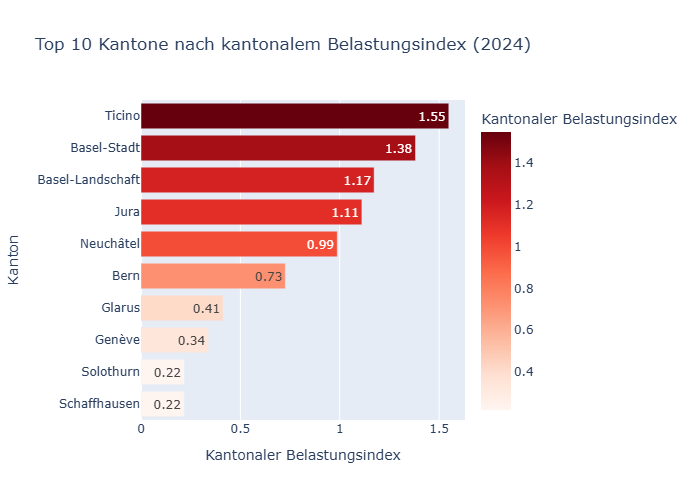

In [8]:
panel_latest = analysis_panel[analysis_panel['year'] == latest_year].copy()

top_belastung = panel_latest.sort_values('belastungsindex', ascending=False)[[
    'canton_code', 'canton_label', 'cost_per_capita', 'population_share_66_plus', 'premium_median_monthly', 'belastungsindex'
]].head(10)

display(top_belastung)

fig = px.bar(
    top_belastung.sort_values('belastungsindex'),
    x='belastungsindex',
    y='canton_label',
    orientation='h',
    title=f'Top 10 Kantone nach kantonalem Belastungsindex ({latest_year})',
    labels={'belastungsindex': 'Kantonaler Belastungsindex', 'canton_label': 'Kanton'},
    text='belastungsindex',
    color='belastungsindex',
    color_continuous_scale='Reds',
)
fig.update_traces(texttemplate='%{text:.2f}')
fig.show()


## SQ1. Welche Kantone haben die höchsten Gesundheitskosten pro Kopf, und wie hat sich dieser Druck seit 2011 entwickelt?

Die erste Leitfrage braucht zwei Blickwinkel:
- aktuelles Niveau der Gesundheitskosten pro Kopf
- Veränderung seit 2011 bzw. seit Beginn des Analysefensters


,canton_code,canton_label,cost_per_capita,population_share_66_plus,premium_median_monthly
343,BS,Basel-Stadt,"13,663.687",0.186,675.200
358,TI,Ticino,"12,800.247",0.227,626.650
350,NE,Neuchâtel,"12,488.764",0.189,657.800
348,JU,Jura,"12,270.684",0.215,602.500
342,BL,Basel-Landschaft,"12,221.672",0.219,605.350
346,GL,Glarus,"11,863.704",0.204,483.800
345,GE,Genève,"11,690.338",0.156,691.400
341,BE,Bern,"11,601.239",0.211,570.450
360,VD,Vaud,"11,393.289",0.159,621.250
355,SO,Solothurn,"10,830.641",0.199,548.500


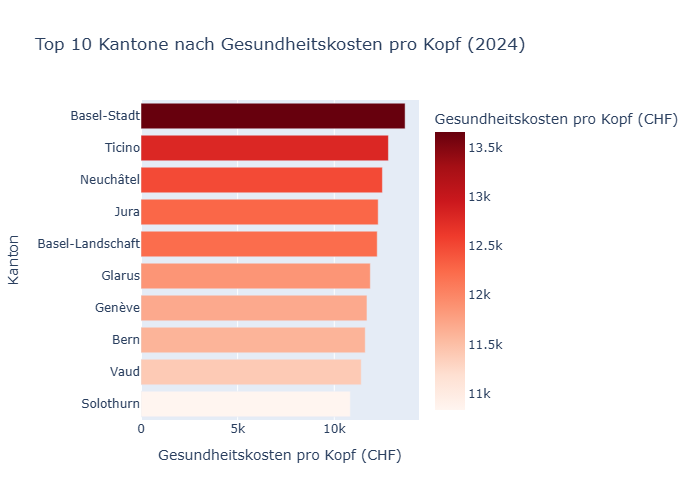

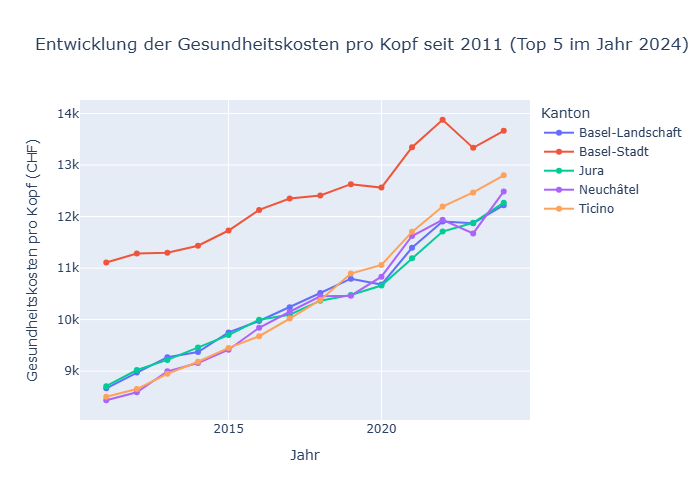

,canton_label,delta_cost_per_capita,delta_age_66_share,delta_premium_median,delta_belastungsindex
20,Ticino,"4,295.826",0.032,237.000,0.448
12,Neuchâtel,"4,054.016",0.020,248.800,0.311
10,Jura,"3,562.652",0.041,216.000,0.331
4,Basel-Landschaft,"3,556.347",0.032,233.850,0.232
8,Glarus,"3,395.744",0.036,188.800,0.240
22,Vaud,"3,051.924",0.012,205.250,-0.231
3,Bern,"3,004.016",0.032,177.900,-0.134
1,Appenzell Innerrhoden,"2,928.149",0.039,166.100,0.369
17,Solothurn,"2,872.541",0.030,218.500,0.099
2,Appenzell Ausserrhoden,"2,733.799",0.035,218.800,0.245


In [9]:
top_cost_latest = panel_latest.sort_values('cost_per_capita', ascending=False)[[
    'canton_code', 'canton_label', 'cost_per_capita', 'population_share_66_plus', 'premium_median_monthly'
]].copy()

display(top_cost_latest.head(10))

fig = px.bar(
    top_cost_latest.head(10).sort_values('cost_per_capita'),
    x='cost_per_capita',
    y='canton_label',
    orientation='h',
    title=f'Top 10 Kantone nach Gesundheitskosten pro Kopf ({latest_year})',
    labels={'cost_per_capita': 'Gesundheitskosten pro Kopf (CHF)', 'canton_label': 'Kanton'},
    color='cost_per_capita',
    color_continuous_scale='Reds',
)
fig.show()

top5_cost_codes = top_cost_latest.head(5)['canton_code'].tolist()
cost_trend_top5 = analysis_panel[analysis_panel['canton_code'].isin(top5_cost_codes)].copy()

fig = px.line(
    cost_trend_top5,
    x='year',
    y='cost_per_capita',
    color='canton_label',
    markers=True,
    title=f'Entwicklung der Gesundheitskosten pro Kopf seit {baseline_year} (Top 5 im Jahr {latest_year})',
    labels={'year': 'Jahr', 'cost_per_capita': 'Gesundheitskosten pro Kopf (CHF)', 'canton_label': 'Kanton'},
)
fig.show()

display(
    trend_compare.sort_values('delta_cost_per_capita', ascending=False)[[
        'canton_label', 'delta_cost_per_capita', 'delta_age_66_share', 'delta_premium_median', 'delta_belastungsindex'
    ]].head(10)
)


## SQ2. Prämienniveau vs. Gesundheitskostenbelastung

Die zweite Leitfrage betrifft nicht nur das absolute Prämienniveau, sondern vor allem die Frage, ob Prämien und Gesundheitskosten pro Kopf in einem Kanton zusammenpassen oder ob es deutliche Abweichungen gibt.


,cost_per_capita,population_share_66_plus,premium_median_monthly,premium_to_cost_ratio,belastungsindex
cost_per_capita,1.000,0.565,0.880,0.234,0.767
population_share_66_plus,0.565,1.000,0.323,-0.204,0.536
premium_median_monthly,0.880,0.323,1.000,0.664,0.577
premium_to_cost_ratio,0.234,-0.204,0.664,1.000,-0.030
belastungsindex,0.767,0.536,0.577,-0.030,1.000


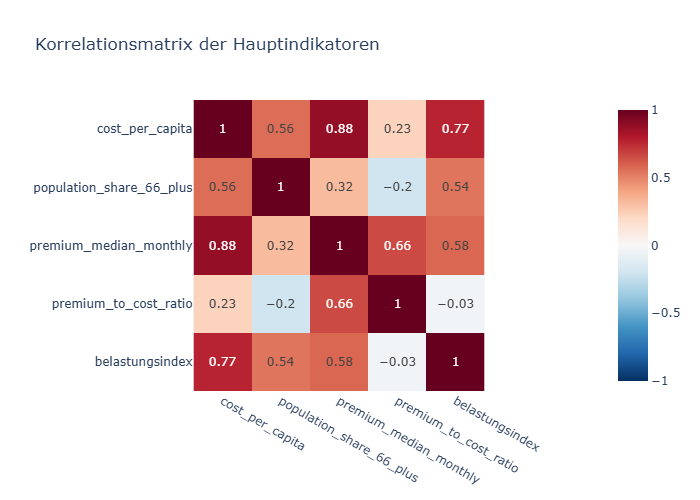

In [10]:
corr = analysis_panel[[
    'cost_per_capita',
    'population_share_66_plus',
    'premium_median_monthly',
    'premium_to_cost_ratio',
    'belastungsindex',
]].corr(numeric_only=True)

display(corr)

fig = px.imshow(
    corr.round(2),
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Korrelationsmatrix der Hauptindikatoren',
)
fig.show()


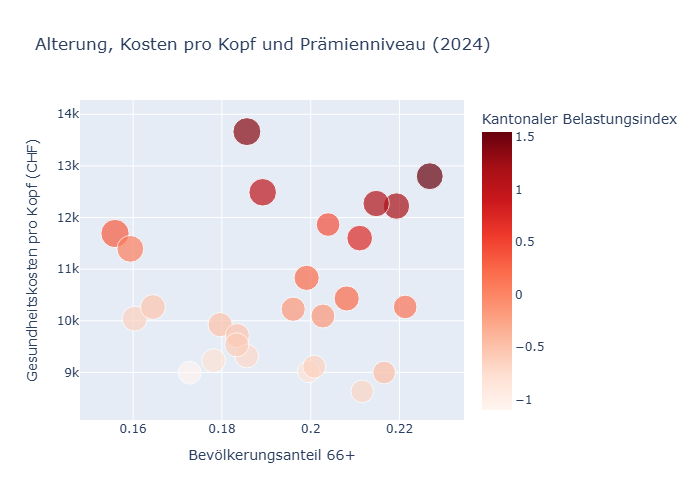

In [11]:
fig = px.scatter(
    panel_latest,
    x='population_share_66_plus',
    y='cost_per_capita',
    size='premium_median_monthly',
    color='belastungsindex',
    hover_name='canton_label',
    color_continuous_scale='Reds',
    title=f'Alterung, Kosten pro Kopf und Prämienniveau ({latest_year})',
    labels={
        'population_share_66_plus': 'Bevölkerungsanteil 66+',
        'cost_per_capita': 'Gesundheitskosten pro Kopf (CHF)',
        'premium_median_monthly': 'Monatliche Median-Basisprämie (Erwachsene)',
        'belastungsindex': 'Kantonaler Belastungsindex',
    },
)
fig.show()


,canton_code,canton_label,cost_per_capita,premium_median_monthly,premium_to_cost_ratio,premium_cost_gap_z,alignment_flag,abs_gap
346,GL,Glarus,"11,863.704",483.800,0.489,-1.652,Prämien unter Kostenprofil,1.652
345,GE,Genève,"11,690.338",691.400,0.710,1.287,Prämien über Kostenprofil,1.287
360,VD,Vaud,"11,393.289",621.250,0.654,0.555,Prämien über Kostenprofil,0.555
347,GR,Graubünden,"10,268.000",481.900,0.563,-0.507,Prämien unter Kostenprofil,0.507
344,FR,Fribourg,"10,040.355",541.350,0.647,0.466,Prämien über Kostenprofil,0.466
358,TI,Ticino,"12,800.247",626.650,0.587,-0.405,Prämien unter Kostenprofil,0.405
349,LU,Luzern,"9,226.824",492.300,0.640,0.398,Prämien über Kostenprofil,0.398
343,BS,Basel-Stadt,"13,663.687",675.200,0.593,-0.381,Prämien unter Kostenprofil,0.381
339,AI,Appenzell Innerrhoden,"9,016.315",425.100,0.566,-0.357,Prämien unter Kostenprofil,0.357
348,JU,Jura,"12,270.684",602.500,0.589,-0.343,Prämien unter Kostenprofil,0.343


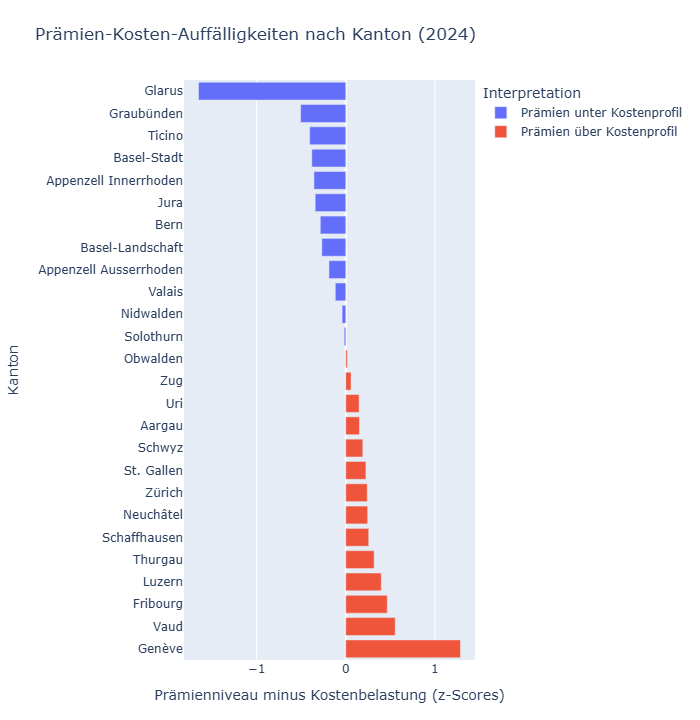

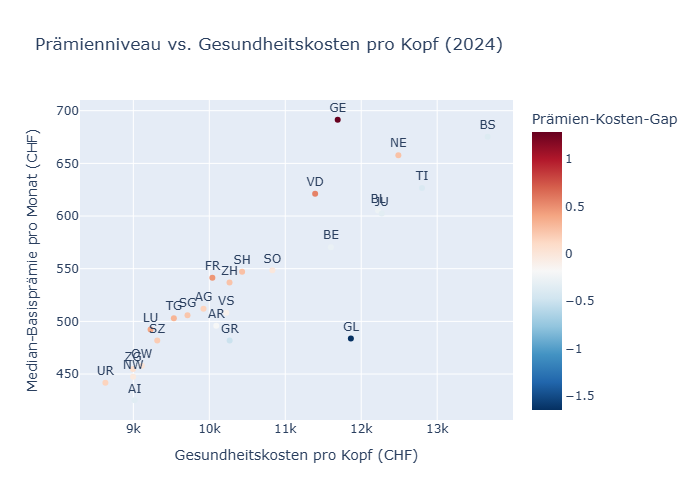

In [12]:
analysis_panel['premium_cost_gap_z'] = analysis_panel['z_premium_median'] - analysis_panel['z_cost_per_capita']
panel_latest = analysis_panel[analysis_panel['year'] == latest_year].copy()
panel_latest['premium_cost_gap_z'] = panel_latest['z_premium_median'] - panel_latest['z_cost_per_capita']
panel_latest['alignment_flag'] = np.where(
    panel_latest['premium_cost_gap_z'] > 0,
    'Prämien über Kostenprofil',
    'Prämien unter Kostenprofil',
)

premium_alignment = panel_latest[[
    'canton_code', 'canton_label', 'cost_per_capita', 'premium_median_monthly',
    'premium_to_cost_ratio', 'premium_cost_gap_z', 'alignment_flag'
]].copy()

premium_alignment['abs_gap'] = premium_alignment['premium_cost_gap_z'].abs()

display(premium_alignment.sort_values('abs_gap', ascending=False).head(10))

premium_alignment_sorted = premium_alignment.sort_values('premium_cost_gap_z').copy()
canton_axis_labels = premium_alignment_sorted['canton_label'].tolist()

fig = px.bar(
    premium_alignment_sorted,
    x='premium_cost_gap_z',
    y='canton_label',
    orientation='h',
    color='alignment_flag',
    category_orders={'canton_label': canton_axis_labels},
    title=f'Prämien-Kosten-Auffälligkeiten nach Kanton ({latest_year})',
    labels={
        'premium_cost_gap_z': 'Prämienniveau minus Kostenbelastung (z-Scores)',
        'canton_label': 'Kanton',
        'alignment_flag': 'Interpretation',
    },
)
fig.update_yaxes(
    title_text='Kanton',
    tickmode='array',
    tickvals=canton_axis_labels,
    ticktext=canton_axis_labels,
    automargin=True,
)
fig.update_layout(height=720, margin=dict(l=170, r=40, t=80, b=60))
fig.show()

fig = px.scatter(
    panel_latest,
    x='cost_per_capita',
    y='premium_median_monthly',
    color='premium_cost_gap_z',
    hover_name='canton_label',
    text='canton_code',
    color_continuous_scale='RdBu_r',
    title=f'Prämienniveau vs. Gesundheitskosten pro Kopf ({latest_year})',
    labels={
        'cost_per_capita': 'Gesundheitskosten pro Kopf (CHF)',
        'premium_median_monthly': 'Median-Basisprämie pro Monat (CHF)',
        'premium_cost_gap_z': 'Prämien-Kosten-Gap',
    },
)
fig.update_traces(textposition='top center')
fig.show()


## SQ3. Wie stark hängt die kantonale Kostenbelastung mit dem Anteil älterer Bevölkerung zusammen?

Hier geht es um den Zusammenhang zwischen Alterung und Kostenbelastung. Relevant sind sowohl der allgemeine Zusammenhang über alle Jahre als auch die Querschnittssituation im aktuellsten Jahr.


In [13]:
latest_age_cost_corr = panel_latest[['population_share_66_plus', 'cost_per_capita']].corr().iloc[0, 1]
print(f'Korrelation im Jahr {latest_year}: {latest_age_cost_corr:.3f}')

age_cost_rank = panel_latest[[
    'canton_label', 'population_share_66_plus', 'cost_per_capita', 'premium_median_monthly', 'belastungsindex'
]].sort_values('population_share_66_plus', ascending=False)

display(age_cost_rank.head(10))


Korrelation im Jahr 2024: 0.132


,canton_label,population_share_66_plus,cost_per_capita,premium_median_monthly,belastungsindex
358,Ticino,0.227,"12,800.247",626.650,1.549
347,Graubünden,0.221,"10,268.000",481.900,0.140
342,Basel-Landschaft,0.219,"12,221.672",605.350,1.173
351,Nidwalden,0.217,"8,997.111",447.400,-0.468
348,Jura,0.215,"12,270.684",602.500,1.111
359,Uri,0.212,"8,632.214",441.700,-0.682
341,Bern,0.211,"11,601.239",570.450,0.726
354,Schaffhausen,0.208,"10,431.863",547.200,0.217
346,Glarus,0.204,"11,863.704",483.800,0.413
340,Appenzell Ausserrhoden,0.203,"10,091.685",495.800,-0.149


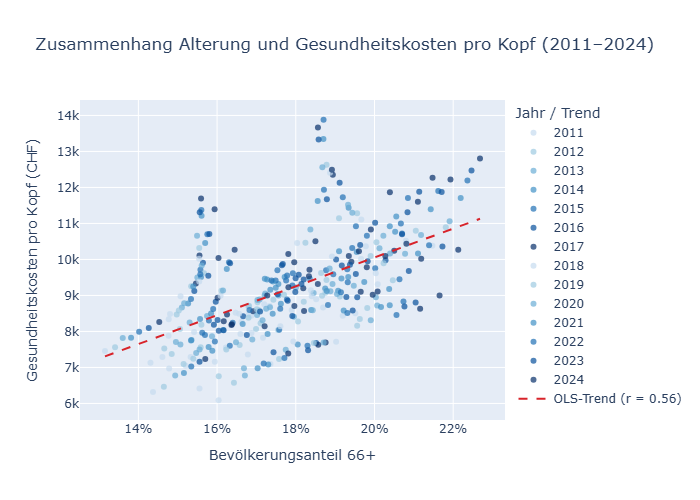

In [14]:
# OLS-Trendlinie über alle Kanton-Jahres-Beobachtungen
_x = analysis_panel['population_share_66_plus'].values
_y = analysis_panel['cost_per_capita'].values
_mask = ~np.isnan(_x) & ~np.isnan(_y)
_coeffs = np.polyfit(_x[_mask], _y[_mask], 1)
_x_line = np.linspace(_x[_mask].min(), _x[_mask].max(), 200)
_y_line = np.polyval(_coeffs, _x_line)

_r = np.corrcoef(_x[_mask], _y[_mask])[0, 1]

_panel_plot = analysis_panel.copy()
_panel_plot['Jahr'] = _panel_plot['year'].astype(str)

fig = px.scatter(
    _panel_plot,
    x='population_share_66_plus',
    y='cost_per_capita',
    color='Jahr',
    hover_name='canton_label',
    hover_data={'Jahr': True, 'population_share_66_plus': ':.3f', 'cost_per_capita': ':,.0f'},
    color_discrete_sequence=px.colors.sequential.Blues[2:],
    category_orders={'Jahr': [str(y) for y in sorted(analysis_panel['year'].unique())]},
    title=f'Zusammenhang Alterung und Gesundheitskosten pro Kopf ({baseline_year}–{latest_year})',
    labels={
        'population_share_66_plus': 'Bevölkerungsanteil 66+',
        'cost_per_capita': 'Gesundheitskosten pro Kopf (CHF)',
    },
    opacity=0.7,
)

fig.add_trace(
    go.Scatter(
        x=_x_line,
        y=_y_line,
        mode='lines',
        name=f'OLS-Trend (r = {_r:.2f})',
        line=dict(color='#d8232a', width=2, dash='dash'),
        showlegend=True,
    )
)

fig.update_layout(
    xaxis_tickformat='.0%',
    legend=dict(title='Jahr / Trend'),
)
fig.show()

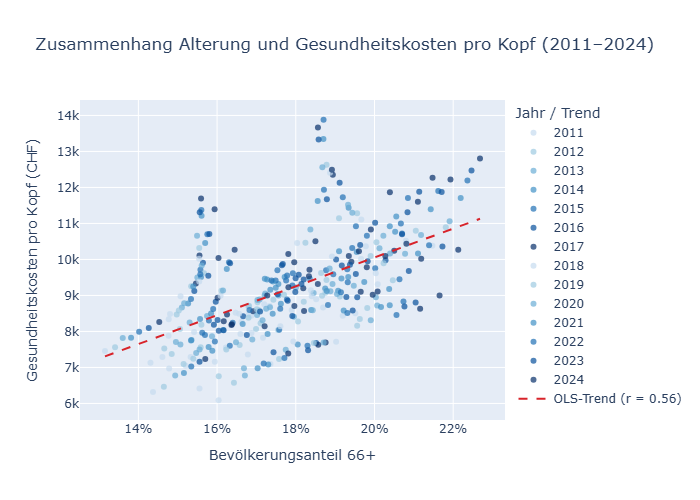

In [15]:
# OLS-Trendlinie über alle Kanton-Jahres-Beobachtungen
_x = analysis_panel['population_share_66_plus'].values
_y = analysis_panel['cost_per_capita'].values
_mask = ~np.isnan(_x) & ~np.isnan(_y)
_coeffs = np.polyfit(_x[_mask], _y[_mask], 1)
_x_line = np.linspace(_x[_mask].min(), _x[_mask].max(), 200)
_y_line = np.polyval(_coeffs, _x_line)

_r = np.corrcoef(_x[_mask], _y[_mask])[0, 1]

_panel_plot = analysis_panel.copy()
_panel_plot['Jahr'] = _panel_plot['year'].astype(str)

fig = px.scatter(
    _panel_plot,
    x='population_share_66_plus',
    y='cost_per_capita',
    color='Jahr',
    hover_name='canton_label',
    hover_data={'Jahr': True, 'population_share_66_plus': ':.3f', 'cost_per_capita': ':,.0f'},
    color_discrete_sequence=px.colors.sequential.Blues[2:],
    category_orders={'Jahr': [str(y) for y in sorted(analysis_panel['year'].unique())]},
    title=f'Zusammenhang Alterung und Gesundheitskosten pro Kopf ({baseline_year}–{latest_year})',
    labels={
        'population_share_66_plus': 'Bevölkerungsanteil 66+',
        'cost_per_capita': 'Gesundheitskosten pro Kopf (CHF)',
    },
    opacity=0.7,
)

fig.add_trace(
    go.Scatter(
        x=_x_line,
        y=_y_line,
        mode='lines',
        name=f'OLS-Trend (r = {_r:.2f})',
        line=dict(color='#d8232a', width=2, dash='dash'),
        showlegend=True,
    )
)

fig.update_layout(
    xaxis_tickformat='.0%',
    legend=dict(title='Jahr / Trend'),
)
fig.show()

### SQ1 Zusatz: Wo ist der Kostendruck seit 2011 am stärksten gestiegen?

Neben dem aktuellen Niveau ist auch relevant, welche Kantone ihren Kostendruck seit dem Start des Analysefensters besonders stark aufgebaut haben.


,canton_label,delta_cost_per_capita,delta_age_66_share,delta_premium_median,delta_belastungsindex
13,Nidwalden,"2,583.831",0.061,187.900,0.638
20,Ticino,"4,295.826",0.032,237.000,0.448
1,Appenzell Innerrhoden,"2,928.149",0.039,166.100,0.369
10,Jura,"3,562.652",0.041,216.000,0.331
12,Neuchâtel,"4,054.016",0.020,248.800,0.311
14,Obwalden,"2,139.533",0.053,171.850,0.255
2,Appenzell Ausserrhoden,"2,733.799",0.035,218.800,0.245
8,Glarus,"3,395.744",0.036,188.800,0.240
4,Basel-Landschaft,"3,556.347",0.032,233.850,0.232
9,Graubünden,"2,445.214",0.050,182.900,0.164


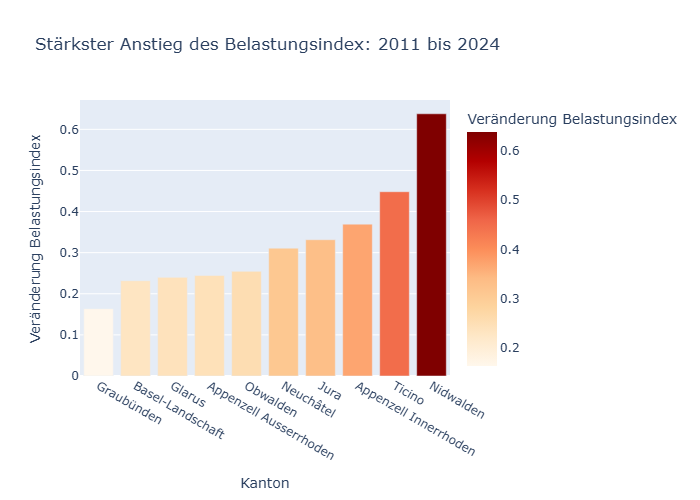

In [16]:

display(
    trend_compare.sort_values('delta_belastungsindex', ascending=False)[[
        'canton_label', 'delta_cost_per_capita', 'delta_age_66_share',
        'delta_premium_median', 'delta_belastungsindex'
    ]].head(10)
)

fig = px.bar(
    trend_compare.sort_values('delta_belastungsindex').tail(10),
    x='canton_label',
    y='delta_belastungsindex',
    title=f'Stärkster Anstieg des Belastungsindex: {baseline_year} bis {latest_year}',
    labels={'canton_label': 'Kanton', 'delta_belastungsindex': 'Veränderung Belastungsindex'},
    color='delta_belastungsindex',
    color_continuous_scale='OrRd',
)
fig.show()


## SQ4. Welche Kantone bilden ähnliche Belastungssegmente?

Um ähnliche kantonale Belastungsmuster zu erkennen, wird eine Clusteranalyse mit Kosten pro Kopf, 66+-Anteil und Median-Basisprämie durchgeführt.


In [17]:
def compute_cluster_compactness(X: np.ndarray, labels: np.ndarray, centers: np.ndarray) -> pd.DataFrame:
    rows = []
    for cluster_id in sorted(np.unique(labels)):
        cluster_points = X[labels == cluster_id]
        sq_distances = ((cluster_points - centers[cluster_id]) ** 2).sum(axis=1)
        rows.append({
            'cluster': int(cluster_id),
            'cluster_size': int(len(cluster_points)),
            'within_cluster_ss': float(sq_distances.sum()),
            'avg_distance_to_center': float(np.sqrt(sq_distances).mean()),
        })
    return pd.DataFrame(rows)


cluster_features = ['cost_per_capita', 'population_share_66_plus', 'premium_median_monthly']
cluster_frame = panel_latest[['canton_code', 'canton_label', 'belastungsindex', *cluster_features]].dropna().copy()

X = cluster_frame[cluster_features].to_numpy(dtype=float)
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

k_eval_rows = []
compactness_rows = []
for k in range(2, 8):
    model_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = model_k.fit_predict(X_scaled)
    centers_k = model_k.cluster_centers_
    inertia_k = float(model_k.inertia_)
    silhouette_k = float(silhouette_score(X_scaled, labels_k))
    compactness_k = compute_cluster_compactness(X_scaled, labels_k, centers_k)
    compactness_k['k'] = k
    compactness_rows.append(compactness_k)

    k_eval_rows.append({
        'k': k,
        'inertia': inertia_k,
        'compactness': inertia_k,
        'silhouette_score': silhouette_k,
        'avg_cluster_compactness': compactness_k['within_cluster_ss'].mean(),
        'max_cluster_compactness': compactness_k['within_cluster_ss'].max(),
    })

cluster_evaluation = pd.DataFrame(k_eval_rows)
compactness_by_k = pd.concat(compactness_rows, ignore_index=True)
compactness_table = (
    compactness_by_k
    .assign(cluster_label=lambda d: 'Cluster ' + (d['cluster'] + 1).astype(str))
    .sort_values(['k', 'cluster'])
    [['k', 'cluster_label', 'cluster_size', 'within_cluster_ss', 'avg_distance_to_center']]
)

print('Cluster-Evaluationsübersicht')
display(cluster_evaluation)
print('Compactness pro k und Cluster')
display(compactness_table)


Cluster-Evaluationsübersicht


,k,inertia,compactness,silhouette_score,avg_cluster_compactness,max_cluster_compactness
0,2,40.260,40.260,0.445,20.130,23.189
1,3,27.271,27.271,0.397,9.090,14.325
2,4,17.717,17.717,0.399,4.429,6.138
3,5,12.386,12.386,0.437,2.477,4.401
4,6,8.890,8.890,0.463,1.482,3.268
5,7,6.648,6.648,0.486,0.950,2.999


Compactness pro k und Cluster


,k,cluster_label,cluster_size,within_cluster_ss,avg_distance_to_center
0,2,Cluster 1,18,23.189,1.048
1,2,Cluster 2,8,17.070,1.377
2,3,Cluster 1,14,14.325,0.901
3,3,Cluster 2,8,8.545,0.960
4,3,Cluster 3,4,4.401,1.041
5,4,Cluster 1,7,6.138,0.852
6,4,Cluster 2,9,4.336,0.614
7,4,Cluster 3,4,4.401,1.041
8,4,Cluster 4,6,2.842,0.663
9,5,Cluster 1,8,3.268,0.587


### Cluster-Qualität prüfen

Bevor wir uns auf eine Clusterzahl festlegen, schauen wir drei Diagnoseelemente an:
- **Elbow Plot**: Wie stark sinkt die Inertia bzw. Compactness bei grösserem `k`?
- **Silhouette Score**: Wie gut sind die Cluster voneinander getrennt und intern zusammenhängend?
- **Compactness-Tabelle**: Wie verteilt sich die innerhalb-Cluster-Streuung für jedes getestete `k`?

Die Compactness wird als Summe der quadrierten Distanzen innerhalb der Cluster gemessen. Je kleiner, desto kompakter. Die Tabelle bleibt im Long-Format, damit keine künstlichen leeren Cluster-Spalten entstehen.


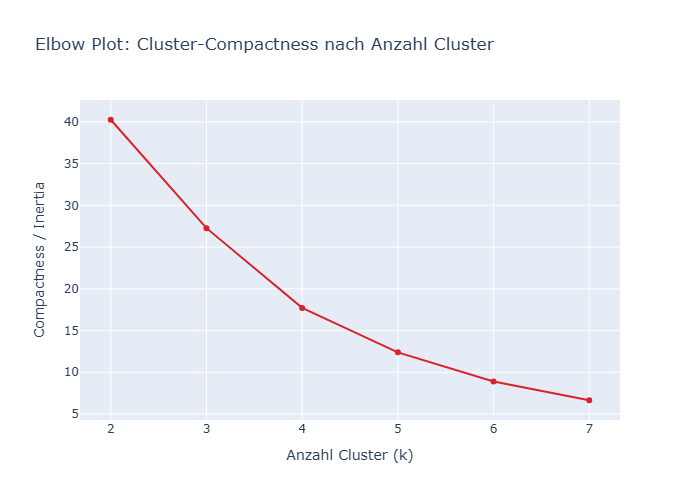

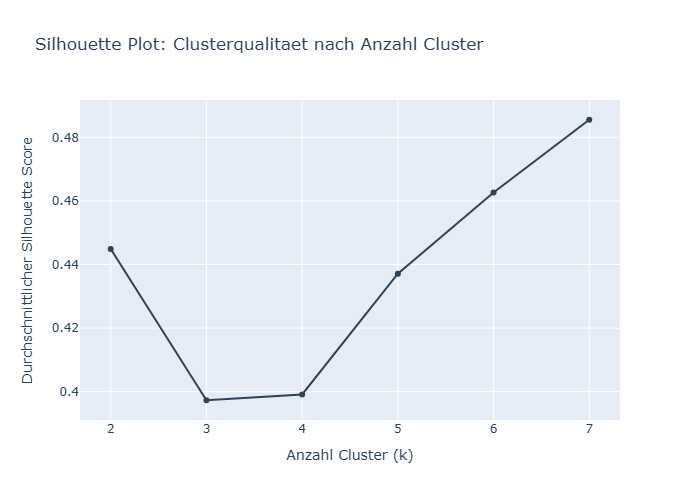

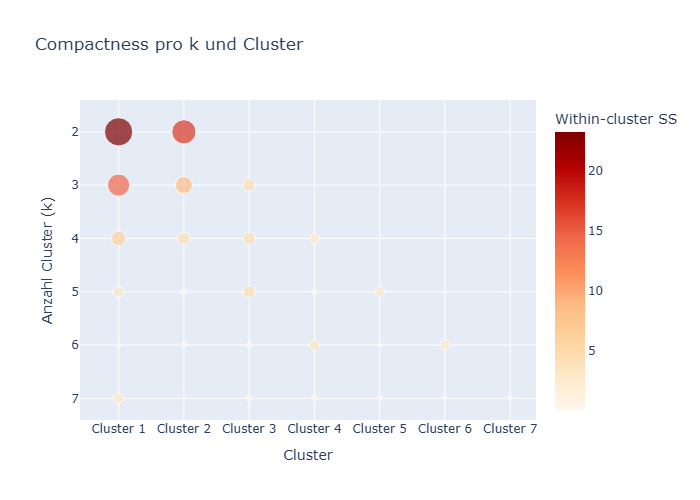

,k,inertia,compactness,silhouette_score,avg_cluster_compactness,max_cluster_compactness
5,7,6.648,6.648,0.486,0.950,2.999
4,6,8.890,8.890,0.463,1.482,3.268
0,2,40.260,40.260,0.445,20.130,23.189
3,5,12.386,12.386,0.437,2.477,4.401
2,4,17.717,17.717,0.399,4.429,6.138
1,3,27.271,27.271,0.397,9.090,14.325


In [18]:
fig = px.line(
    cluster_evaluation,
    x='k',
    y='compactness',
    markers=True,
    title='Elbow Plot: Cluster-Compactness nach Anzahl Cluster',
    labels={'k': 'Anzahl Cluster (k)', 'compactness': 'Compactness / Inertia'},
)
fig.update_traces(line_color='#d8232a')
fig.show()

fig = px.line(
    cluster_evaluation,
    x='k',
    y='silhouette_score',
    markers=True,
    title='Silhouette Plot: Clusterqualitaet nach Anzahl Cluster',
    labels={'k': 'Anzahl Cluster (k)', 'silhouette_score': 'Durchschnittlicher Silhouette Score'},
)
fig.update_traces(line_color='#2f4356')
fig.show()

fig = px.scatter(
    compactness_table,
    x='cluster_label',
    y='k',
    size='within_cluster_ss',
    color='within_cluster_ss',
    hover_data={
        'cluster_size': True,
        'avg_distance_to_center': ':.3f',
        'within_cluster_ss': ':.3f',
    },
    color_continuous_scale='OrRd',
    title='Compactness pro k und Cluster',
    labels={
        'cluster_label': 'Cluster',
        'k': 'Anzahl Cluster (k)',
        'within_cluster_ss': 'Within-cluster SS',
    },
)
fig.update_yaxes(dtick=1, autorange='reversed')
fig.show()

cluster_evaluation.sort_values('silhouette_score', ascending=False)


Gewähltes k: 6
Overall compactness (inertia): 8.890
Overall silhouette score: 0.463


,cluster,cost_per_capita,population_share_66_plus,premium_median_monthly,belastungsindex,cluster_rank,cluster_name
3,3,"9,626.724",0.176,503.500,-0.678,1,Niedriger Druck
1,1,"8,939.201",0.207,443.012,-0.643,2,Mittlerer Druck
5,5,"10,618.253",0.205,510.900,0.112,3,Erhöhter Druck
0,0,"11,541.814",0.158,656.325,0.197,4,Hoher Druck
2,2,"12,223.461",0.218,601.237,1.140,5,Sehr hoher Druck
4,4,"13,076.226",0.187,666.500,1.184,6,Extremer Druck


,cluster,cluster_size,within_cluster_ss,avg_distance_to_center,cluster_name
4,4,2,0.415,0.456,Extremer Druck
0,0,2,0.490,0.495,Hoher Druck
1,1,4,0.689,0.410,Mittlerer Druck
2,2,4,1.030,0.416,Sehr hoher Druck
5,5,6,2.999,0.676,Erhöhter Druck
3,3,8,3.268,0.587,Niedriger Druck


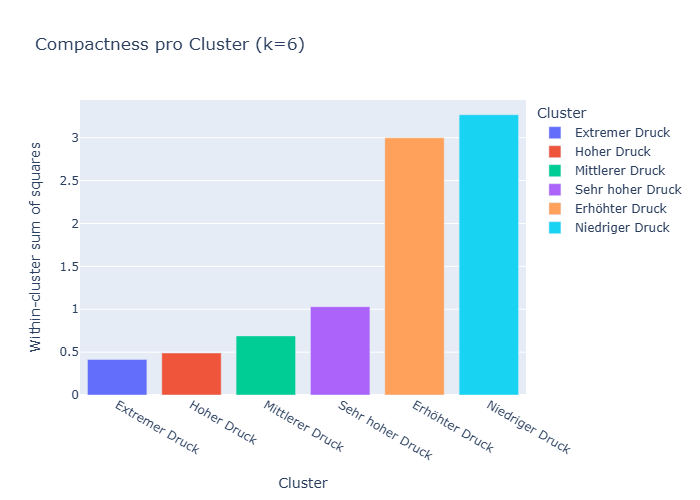

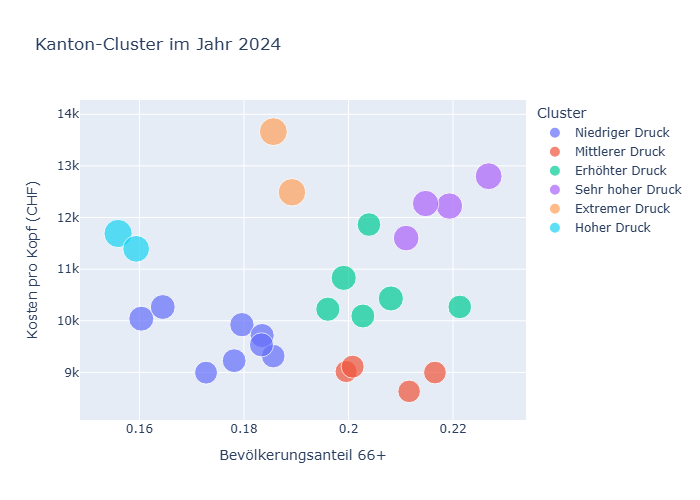

In [19]:
chosen_k = 6
cluster_model = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
labels = cluster_model.fit_predict(X_scaled)
centers = cluster_model.cluster_centers_
cluster_frame['cluster'] = labels

cluster_profile = cluster_frame.groupby('cluster', as_index=False)[cluster_features + ['belastungsindex']].mean()
cluster_profile['cluster_rank'] = cluster_profile['belastungsindex'].rank(ascending=True, method='dense').astype(int)

rank_to_name = {1: 'Niedriger Druck', 2: 'Mittlerer Druck', 3: 'Erhöhter Druck', 4: 'Hoher Druck', 5: 'Sehr hoher Druck', 6: 'Extremer Druck'}
cluster_profile['cluster_name'] = cluster_profile['cluster_rank'].map(rank_to_name)
cluster_name_map = cluster_profile.set_index('cluster')['cluster_name'].to_dict()
cluster_frame['cluster_name'] = cluster_frame['cluster'].map(cluster_name_map)

cluster_compactness = compute_cluster_compactness(X_scaled, labels, centers)
cluster_compactness['cluster_name'] = cluster_compactness['cluster'].map(cluster_name_map)
overall_compactness = float(cluster_model.inertia_)
overall_silhouette = float(silhouette_score(X_scaled, labels))

print(f'Gewähltes k: {chosen_k}')
print(f'Overall compactness (inertia): {overall_compactness:,.3f}')
print(f'Overall silhouette score: {overall_silhouette:,.3f}')

display(cluster_profile.sort_values('cluster_rank'))
display(cluster_compactness.sort_values('within_cluster_ss'))

fig = px.bar(
    cluster_compactness.sort_values('within_cluster_ss'),
    x='cluster_name',
    y='within_cluster_ss',
    color='cluster_name',
    title=f'Compactness pro Cluster (k={chosen_k})',
    labels={'cluster_name': 'Cluster', 'within_cluster_ss': 'Within-cluster sum of squares'},
)
fig.show()

fig = px.scatter(
    cluster_frame,
    x='population_share_66_plus',
    y='cost_per_capita',
    color='cluster_name',
    size='premium_median_monthly',
    hover_name='canton_label',
    title=f'Kanton-Cluster im Jahr {latest_year}',
    labels={
        'population_share_66_plus': 'Bevölkerungsanteil 66+',
        'cost_per_capita': 'Kosten pro Kopf (CHF)',
        'premium_median_monthly': 'Monatliche Median-Basisprämie (Erwachsene)',
        'cluster_name': 'Cluster',
    },
)
fig.show()


## SQ4 Zusatzperspektive: Cluster nach Altersprofil

Neben der Gesamtbelastung ist auch interessant, wie sich die Gesundheitskosten innerhalb eines Kantons über die Altersgruppen verteilen. So lassen sich Kantone mit ähnlicher demografischer Kostenstruktur identifizieren.


In [20]:
age_order = [
    '0-5 years', '6-10 years', '11-15 years', '16-20 years', '21-25 years',
    '26-30 years', '31-35 years', '36-40 years', '41-45 years', '46-50 years',
    '51-55 years', '56-60 years', '61-65 years', '66-70 years', '71-75 years',
    '76-80 years', '81-85 years', '86-90 years', '91-95 years', '96+ years',
]

age_cost_latest = (
    df_costs[
        (df_costs['year'] == latest_year)
        & (df_costs['cantons'] != 'Total')
        & (df_costs['age'] != 'Total')
    ][['cantons', 'age', 'costs_chf']]
    .copy()
)
age_cost_latest['canton_code'] = age_cost_latest['cantons'].map(CANTON_NAME_TO_CODE)
age_cost_latest['canton_label'] = age_cost_latest['canton_code'].map(CODE_TO_LABEL)

age_profile = (
    age_cost_latest
    .pivot_table(index=['canton_code', 'canton_label'], columns='age', values='costs_chf', aggfunc='sum')
    .reindex(columns=age_order)
    .fillna(0)
)

age_profile_share = age_profile.div(age_profile.sum(axis=1), axis=0)
age_profile_share = age_profile_share.reset_index()

age_cluster_frame = age_profile_share.copy()
age_feature_cols = age_order.copy()

age_feature_frame = age_cluster_frame[age_feature_cols].copy()
valid_age_feature_cols = [
    col for col in age_feature_cols
    if age_feature_frame[col].notna().all() and age_feature_frame[col].std() > 0
]
dropped_age_feature_cols = [
    col for col in age_feature_cols
    if col not in valid_age_feature_cols
]

print('Verwendete Altersgruppen für Clustering:', valid_age_feature_cols)
print('Gedroppte Altersgruppen ohne verwertbare Varianz:', dropped_age_feature_cols)

X_age = age_feature_frame[valid_age_feature_cols].to_numpy(dtype=float)
age_scaler = StandardScaler()
X_age_scaled = age_scaler.fit_transform(X_age)

age_k_eval_rows = []
age_compactness_rows = []
for k in range(2, 8):
    age_model_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    age_labels_k = age_model_k.fit_predict(X_age_scaled)
    age_centers_k = age_model_k.cluster_centers_
    inertia_k = float(age_model_k.inertia_)
    silhouette_k = float(silhouette_score(X_age_scaled, age_labels_k))
    compactness_k = compute_cluster_compactness(X_age_scaled, age_labels_k, age_centers_k)
    compactness_k['k'] = k
    age_compactness_rows.append(compactness_k)
    age_k_eval_rows.append({
        'k': k,
        'compactness': inertia_k,
        'silhouette_score': silhouette_k,
    })

age_cluster_evaluation = pd.DataFrame(age_k_eval_rows)
age_compactness_by_k = pd.concat(age_compactness_rows, ignore_index=True)
age_compactness_table = (
    age_compactness_by_k
    .assign(cluster_label=lambda d: 'Cluster ' + (d['cluster'] + 1).astype(str))
    .sort_values(['k', 'cluster'])
    [['k', 'cluster_label', 'cluster_size', 'within_cluster_ss', 'avg_distance_to_center']]
)

display(age_cluster_evaluation)
display(age_compactness_table)


Verwendete Altersgruppen für Clustering: ['0-5 years', '6-10 years', '11-15 years', '16-20 years', '21-25 years', '26-30 years', '31-35 years', '36-40 years', '41-45 years', '46-50 years', '51-55 years', '56-60 years', '61-65 years', '66-70 years', '71-75 years', '76-80 years', '81-85 years', '86-90 years', '91-95 years']
Gedroppte Altersgruppen ohne verwertbare Varianz: ['96+ years']


,k,compactness,silhouette_score
0,2,360.443,0.208
1,3,298.118,0.225
2,4,244.684,0.198
3,5,218.098,0.190
4,6,193.685,0.122
5,7,169.243,0.132


,k,cluster_label,cluster_size,within_cluster_ss,avg_distance_to_center
0,2,Cluster 1,17,295.944,3.968
1,2,Cluster 2,9,64.499,2.623
2,3,Cluster 1,16,233.619,3.706
3,3,Cluster 2,9,64.499,2.623
4,3,Cluster 3,1,0.000,0.000
5,4,Cluster 1,12,127.882,3.183
6,4,Cluster 2,9,64.499,2.623
7,4,Cluster 3,4,52.302,3.530
8,4,Cluster 4,1,0.000,0.000
9,5,Cluster 1,1,0.000,0.000


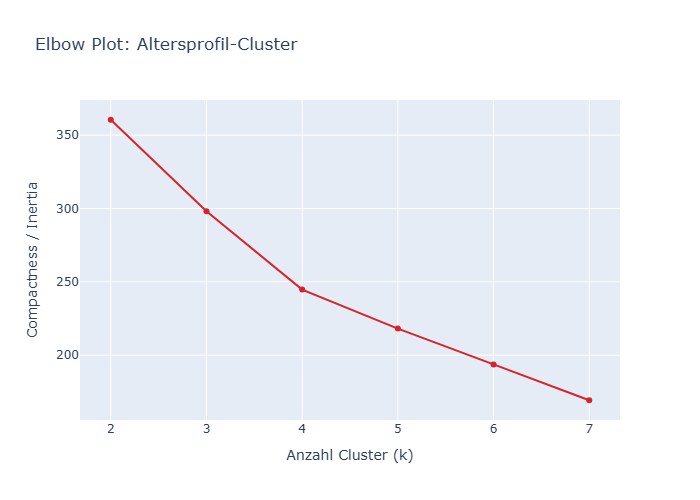

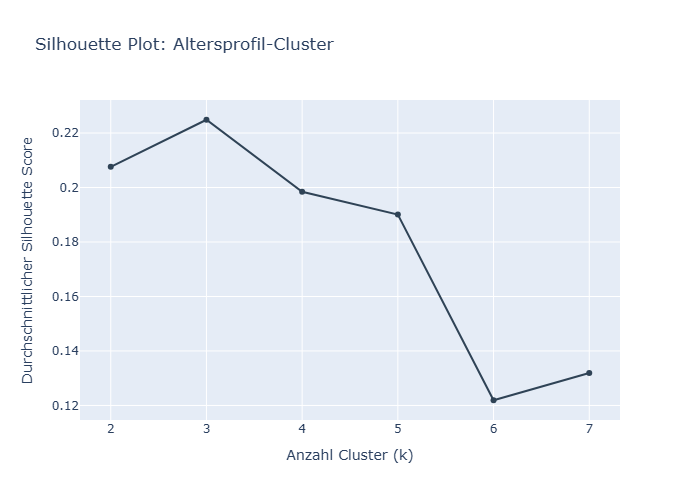

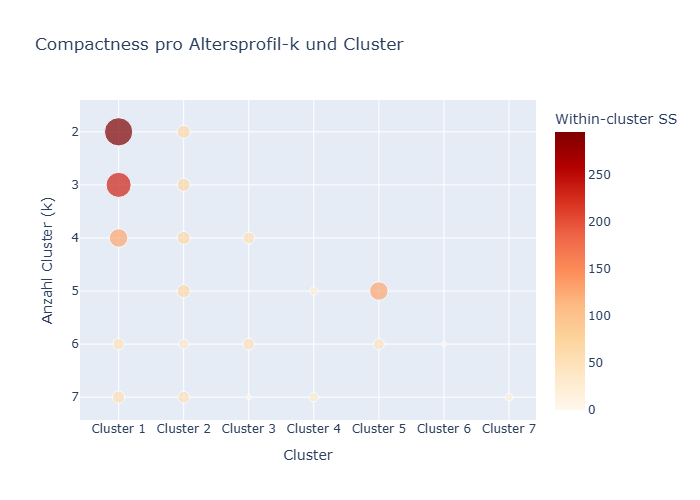

In [21]:
fig = px.line(
    age_cluster_evaluation,
    x='k',
    y='compactness',
    markers=True,
    title='Elbow Plot: Altersprofil-Cluster',
    labels={'k': 'Anzahl Cluster (k)', 'compactness': 'Compactness / Inertia'},
)
fig.update_traces(line_color='#d8232a')
fig.show()

fig = px.line(
    age_cluster_evaluation,
    x='k',
    y='silhouette_score',
    markers=True,
    title='Silhouette Plot: Altersprofil-Cluster',
    labels={'k': 'Anzahl Cluster (k)', 'silhouette_score': 'Durchschnittlicher Silhouette Score'},
)
fig.update_traces(line_color='#2f4356')
fig.show()

fig = px.scatter(
    age_compactness_table,
    x='cluster_label',
    y='k',
    size='within_cluster_ss',
    color='within_cluster_ss',
    hover_data={
        'cluster_size': True,
        'avg_distance_to_center': ':.3f',
        'within_cluster_ss': ':.3f',
    },
    color_continuous_scale='OrRd',
    title='Compactness pro Altersprofil-k und Cluster',
    labels={
        'cluster_label': 'Cluster',
        'k': 'Anzahl Cluster (k)',
        'within_cluster_ss': 'Within-cluster SS',
    },
)
fig.update_yaxes(dtick=1, autorange='reversed')
fig.show()


Gewähltes k für Altersprofil-Cluster: 3
Overall compactness: 298.118
Overall silhouette score: 0.225


age,age_cluster,cluster_name,younger_share,older_share,0-5 years,6-10 years,11-15 years,16-20 years,21-25 years,26-30 years,31-35 years,36-40 years,41-45 years,46-50 years,51-55 years,56-60 years,61-65 years,66-70 years,71-75 years,76-80 years,81-85 years,86-90 years,91-95 years
0,0,Älteres Kostenprofil,0.132,0.495,0.021,0.012,0.016,0.024,0.025,0.033,0.040,0.039,0.039,0.043,0.058,0.072,0.082,0.080,0.088,0.098,0.094,0.082,0.054
1,1,Ausgeglichenes Profil,0.151,0.446,0.026,0.014,0.018,0.028,0.028,0.037,0.045,0.046,0.047,0.050,0.063,0.075,0.077,0.075,0.080,0.090,0.085,0.072,0.045
2,2,Jüngeres Kostenprofil,0.257,0.403,0.019,0.013,0.015,0.022,0.024,0.164,0.033,0.035,0.038,0.045,0.051,0.063,0.075,0.068,0.076,0.082,0.071,0.063,0.042


,cluster,cluster_size,within_cluster_ss,avg_distance_to_center,cluster_name
2,2,1,0.000,0.000,Jüngeres Kostenprofil
1,1,9,64.499,2.623,Ausgeglichenes Profil
0,0,16,233.619,3.706,Älteres Kostenprofil


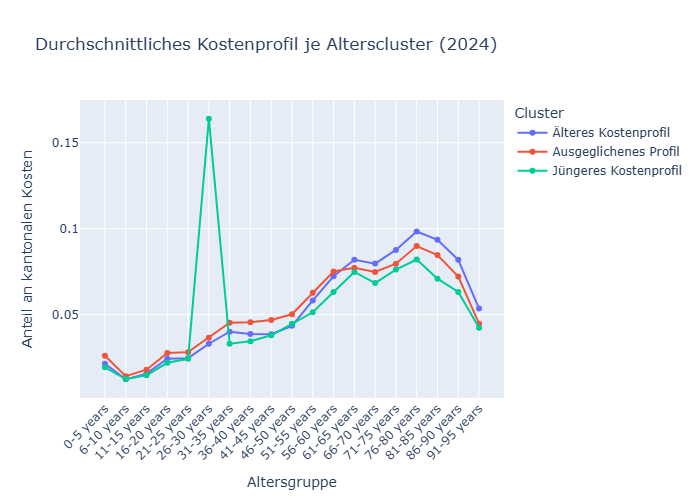

In [22]:
chosen_k_age = 3
age_cluster_model = KMeans(n_clusters=chosen_k_age, random_state=42, n_init=20)
age_labels = age_cluster_model.fit_predict(X_age_scaled)
age_centers = age_cluster_model.cluster_centers_
age_cluster_frame['age_cluster'] = age_labels

age_cluster_profile = age_cluster_frame.groupby('age_cluster', as_index=False)[valid_age_feature_cols].mean()
age_cluster_profile['older_share'] = age_cluster_profile[[
    col for col in ['66-70 years', '71-75 years', '76-80 years', '81-85 years', '86-90 years', '91-95 years', '96+ years']
    if col in valid_age_feature_cols
]].sum(axis=1)
age_cluster_profile['younger_share'] = age_cluster_profile[[
    col for col in ['0-5 years', '6-10 years', '11-15 years', '16-20 years', '21-25 years', '26-30 years']
    if col in valid_age_feature_cols
]].sum(axis=1)
age_cluster_profile['cluster_rank'] = age_cluster_profile['older_share'].rank(ascending=True, method='dense').astype(int)

age_rank_to_name = {
    1: 'Jüngeres Kostenprofil',
    2: 'Ausgeglichenes Profil',
    3: 'Älteres Kostenprofil',
    4: 'Stark älteres Kostenprofil',
    5: 'Sehr stark älteres Kostenprofil',
    6: 'Extrem älteres Kostenprofil',
}
age_cluster_profile['cluster_name'] = age_cluster_profile['cluster_rank'].map(age_rank_to_name)
age_cluster_name_map = age_cluster_profile.set_index('age_cluster')['cluster_name'].to_dict()
age_cluster_frame['cluster_name'] = age_cluster_frame['age_cluster'].map(age_cluster_name_map)

age_cluster_compactness = compute_cluster_compactness(X_age_scaled, age_labels, age_centers)
age_cluster_compactness['cluster_name'] = age_cluster_compactness['cluster'].map(age_cluster_name_map)

print(f'Gewähltes k für Altersprofil-Cluster: {chosen_k_age}')
print(f'Overall compactness: {float(age_cluster_model.inertia_):,.3f}')
print(f'Overall silhouette score: {float(silhouette_score(X_age_scaled, age_labels)):.3f}')

display(age_cluster_profile[['age_cluster', 'cluster_name', 'younger_share', 'older_share'] + valid_age_feature_cols])
display(age_cluster_compactness.sort_values('within_cluster_ss'))

age_cluster_profile_long = age_cluster_profile.melt(
    id_vars=['age_cluster', 'cluster_name', 'younger_share', 'older_share'],
    value_vars=valid_age_feature_cols,
    var_name='age_group',
    value_name='cost_share',
)

fig = px.line(
    age_cluster_profile_long,
    x='age_group',
    y='cost_share',
    color='cluster_name',
    markers=True,
    title=f'Durchschnittliches Kostenprofil je Alterscluster ({latest_year})',
    labels={
        'age_group': 'Altersgruppe',
        'cost_share': 'Anteil an kantonalen Kosten',
        'cluster_name': 'Cluster',
    },
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()


## SQ4 Vorbereitung der Projektion: Linearität prüfen

Bevor wir bis 2030 linear fortschreiben, prüfen wir, ob die Zeitreihen eine lineare Annäherung überhaupt halbwegs tragen.


In [23]:
def build_linear_fit_frame(df: pd.DataFrame, value_col: str, group_col: str, selected_groups: list[str]) -> pd.DataFrame:
    rows = []
    for group_value in selected_groups:
        g = df[df[group_col] == group_value][['year', value_col]].dropna().sort_values('year').copy()
        if len(g) < 2:
            continue

        model = LinearRegression()
        X = g[['year']].to_numpy(dtype=float)
        y = g[value_col].to_numpy(dtype=float)
        model.fit(X, y)

        g['actual_value'] = g[value_col]
        g['linear_fit'] = model.predict(X)
        g[group_col] = group_value
        g['r2'] = float(model.score(X, y))
        rows.append(g[['year', group_col, 'actual_value', 'linear_fit', 'r2']])

    return pd.concat(rows, ignore_index=True)


swiss_panel = (
    analysis_panel
    .groupby('year', as_index=False)
    .agg(
        cost_per_capita=('cost_per_capita', 'mean'),
        population_share_66_plus=('population_share_66_plus', 'mean'),
        premium_median_monthly=('premium_median_monthly', 'mean'),
    )
    .assign(entity='Schweiz (Kantonsmittel)')
)

example_cantons = (
    panel_latest
    .sort_values('belastungsindex', ascending=False)
    ['canton_code']
    .head(3)
    .tolist()
)
example_cantons += (
    panel_latest
    .sort_values('belastungsindex', ascending=True)
    ['canton_code']
    .head(2)
    .tolist()
)
example_cantons = list(dict.fromkeys(example_cantons))
print('Beispielkantone für Linearitätscheck:', example_cantons)


Beispielkantone für Linearitätscheck: ['TI', 'BS', 'BL', 'ZG', 'LU']


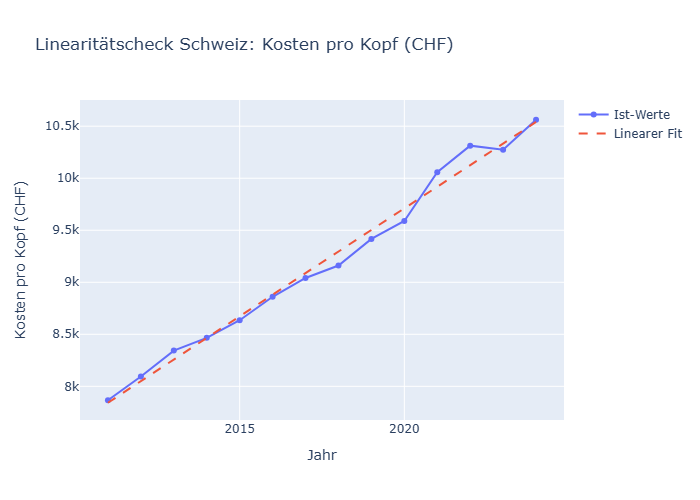

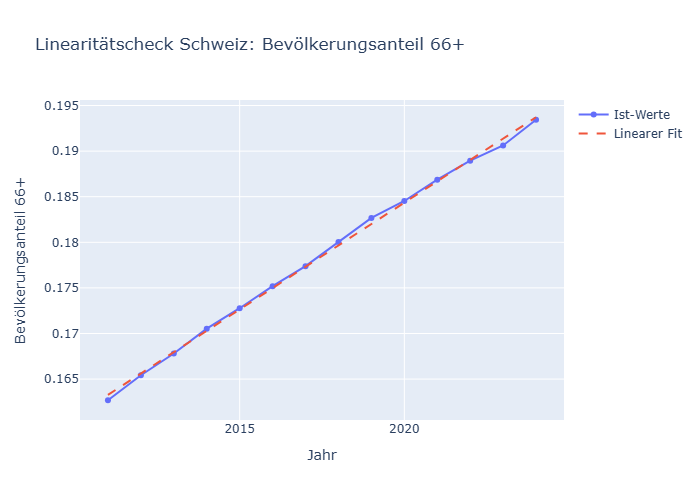

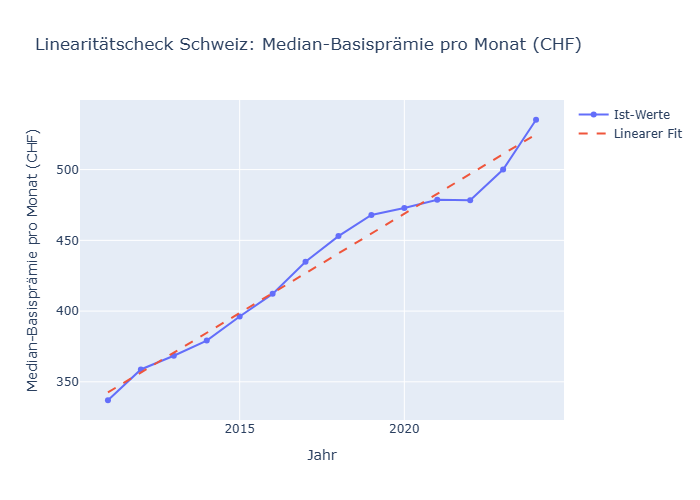

In [24]:
metrics_to_check = [
    ('cost_per_capita', 'Kosten pro Kopf (CHF)'),
    ('population_share_66_plus', 'Bevölkerungsanteil 66+'),
    ('premium_median_monthly', 'Median-Basisprämie pro Monat (CHF)'),
]

for metric_col, metric_label in metrics_to_check:
    fit_swiss = build_linear_fit_frame(swiss_panel, metric_col, 'entity', ['Schweiz (Kantonsmittel)'])

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=fit_swiss['year'], y=fit_swiss['actual_value'], mode='lines+markers', name='Ist-Werte'
    ))
    fig.add_trace(go.Scatter(
        x=fit_swiss['year'], y=fit_swiss['linear_fit'], mode='lines', name='Linearer Fit', line=dict(dash='dash')
    ))
    fig.update_layout(
        title=f'Linearitätscheck Schweiz: {metric_label}',
        xaxis_title='Jahr',
        yaxis_title=metric_label,
    )
    fig.show()


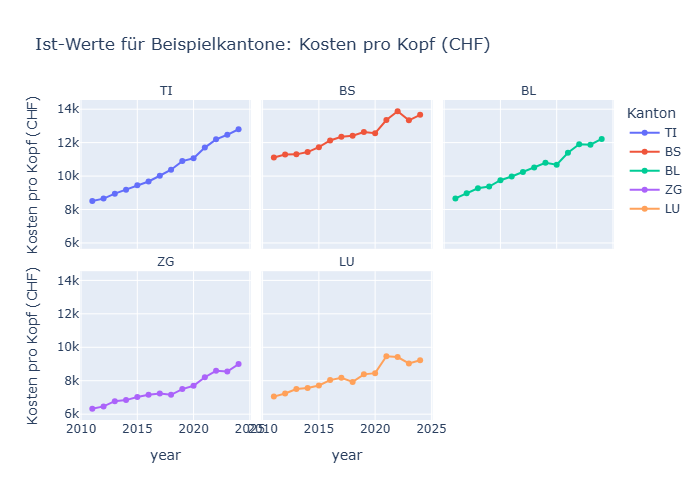

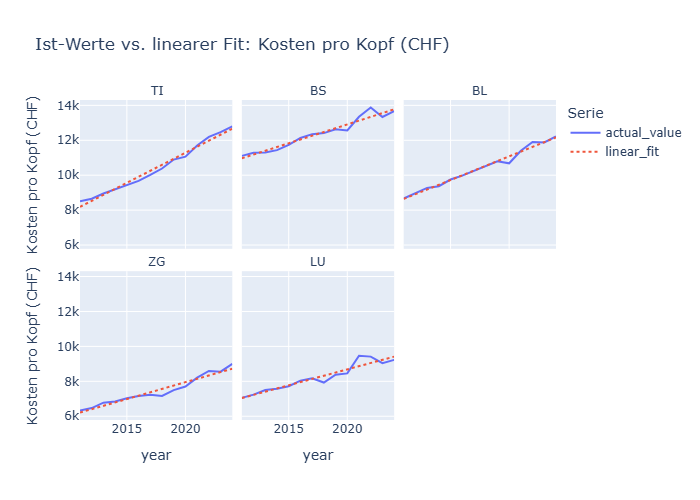

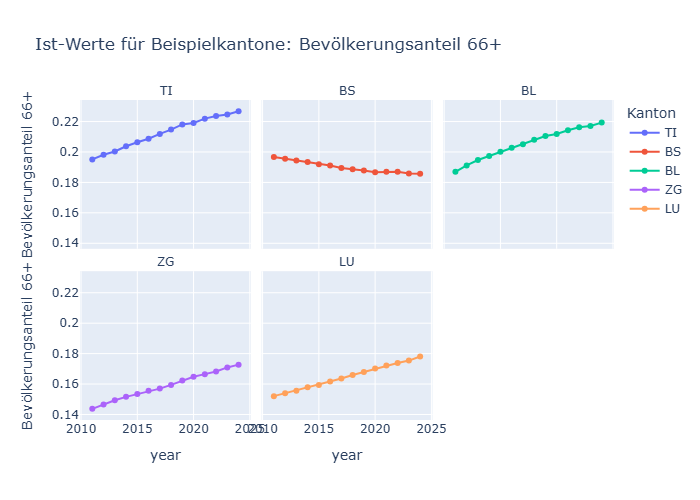

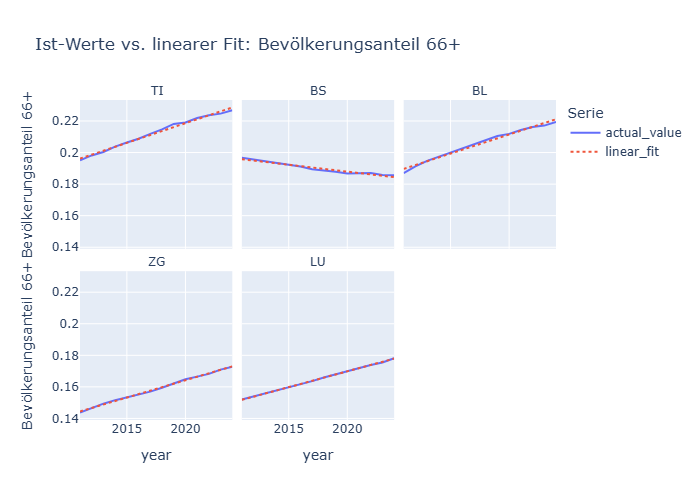

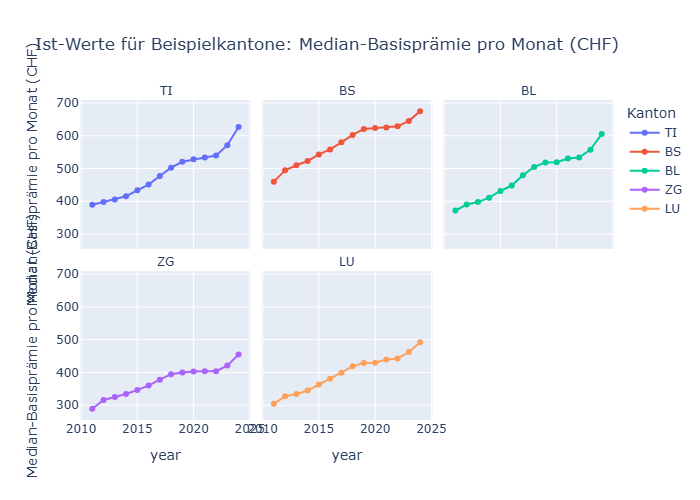

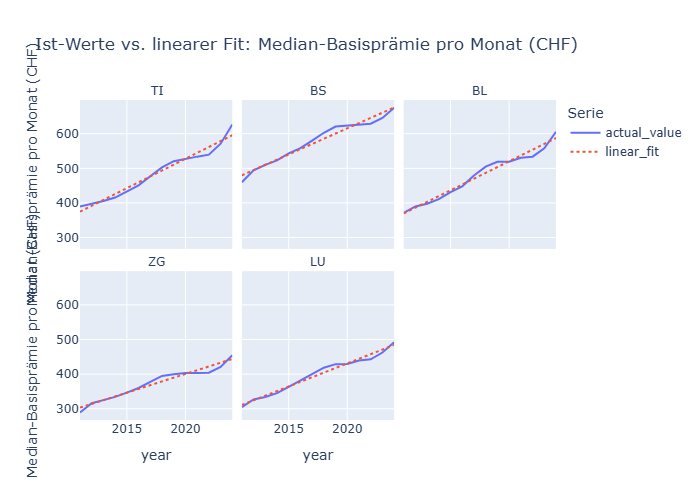

In [25]:
for metric_col, metric_label in metrics_to_check:
    fit_examples = build_linear_fit_frame(analysis_panel, metric_col, 'canton_code', example_cantons)

    fig = px.line(
        fit_examples,
        x='year',
        y='actual_value',
        color='canton_code',
        markers=True,
        facet_col='canton_code',
        facet_col_wrap=3,
        title=f'Ist-Werte für Beispielkantone: {metric_label}',
        labels={'actual_value': metric_label, 'canton_code': 'Kanton'},
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
    fig.show()

    fig = px.line(
        fit_examples.melt(
            id_vars=['year', 'canton_code', 'r2'],
            value_vars=['actual_value', 'linear_fit'],
            var_name='series',
            value_name='value',
        ),
        x='year',
        y='value',
        color='series',
        facet_col='canton_code',
        facet_col_wrap=3,
        line_dash='series',
        title=f'Ist-Werte vs. linearer Fit: {metric_label}',
        labels={'value': metric_label, 'canton_code': 'Kanton', 'series': 'Serie'},
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
    fig.show()


,canton_code,canton_label,cost_per_capita_r2,population_share_66_plus_r2,premium_median_monthly_r2,avg_r2
19,TG,Thurgau,0.985,0.998,0.981,0.988
12,NE,Neuchâtel,0.980,0.996,0.982,0.986
10,JU,Jura,0.979,0.997,0.980,0.986
3,BE,Bern,0.980,0.999,0.970,0.983
15,SG,St. Gallen,0.982,0.991,0.970,0.981
4,BL,Basel-Landschaft,0.984,0.984,0.973,0.981
14,OW,Obwalden,0.964,0.999,0.977,0.980
20,TI,Ticino,0.984,0.990,0.966,0.980
9,GR,Graubünden,0.962,0.996,0.981,0.980
6,FR,Fribourg,0.959,0.998,0.982,0.980


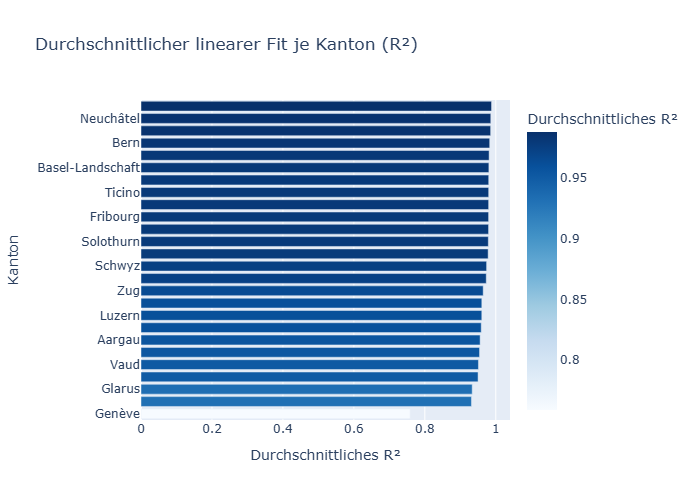

In [26]:
def compute_r2_table(df: pd.DataFrame, metrics: list[tuple[str, str]]) -> pd.DataFrame:
    rows = []
    for canton_code, group in df.groupby('canton_code'):
        row = {
            'canton_code': canton_code,
            'canton_label': group['canton_label'].iloc[0],
        }
        for metric_col, _ in metrics:
            g = group[['year', metric_col]].dropna().sort_values('year')
            if len(g) < 2:
                row[f'{metric_col}_r2'] = np.nan
                continue
            model = LinearRegression()
            X = g[['year']].to_numpy(dtype=float)
            y = g[metric_col].to_numpy(dtype=float)
            model.fit(X, y)
            row[f'{metric_col}_r2'] = float(model.score(X, y))
        rows.append(row)
    return pd.DataFrame(rows)


linear_fit_quality = compute_r2_table(analysis_panel, metrics_to_check)
linear_fit_quality['avg_r2'] = linear_fit_quality[[
    'cost_per_capita_r2', 'population_share_66_plus_r2', 'premium_median_monthly_r2'
]].mean(axis=1)

linear_fit_quality = linear_fit_quality.sort_values('avg_r2', ascending=False)
display(linear_fit_quality)

fig = px.bar(
    linear_fit_quality.sort_values('avg_r2'),
    x='avg_r2',
    y='canton_label',
    orientation='h',
    title='Durchschnittlicher linearer Fit je Kanton (R²)',
    labels={'avg_r2': 'Durchschnittliches R²', 'canton_label': 'Kanton'},
    color='avg_r2',
    color_continuous_scale='Blues',
)
fig.show()


### Einordnung der Linearität

Die `R²`-Werte zeigen, dass die drei zentralen Kennzahlen in den meisten Kantonen sehr gut durch lineare Trends beschrieben werden können. Die durchschnittlichen `R²`-Werte liegen überwiegend auf einem sehr hohen Niveau und bewegen sich meist zwischen rund `0.92` und `0.99`.

Besonders deutlich ist die lineare Entwicklung beim Anteil der Bevölkerung `66+`, aber auch `Kosten pro Kopf` und `Median-Basisprämien` verlaufen in den meisten Kantonen sehr stabil.

Wichtig bleibt trotzdem: Die Projektion ist eine **vereinfachte Trendfortschreibung**. Einzelne Ausnahmen, insbesondere Kantone mit tieferen `R²`-Werten in einzelnen Kennzahlen, sollten in der Interpretation vorsichtig behandelt werden.


## SQ4. Wie entwickeln sich die Belastungssegmente bis 2030?

Für eine einfache, transparente Vorausschau wird je Kanton und Kennzahl ein linearer Trend geschätzt.


,canton_label,cost_per_capita_2030,population_share_66_plus_2030,premium_median_monthly_2030,belastungsindex_2030,delta_belastungsindex_to_2030,cost_per_capita_r2,population_share_66_plus_r2,premium_median_monthly_r2
20,Ticino,"14,730.582",0.244,697.683,1.579,0.030,0.984,0.990,0.966
4,Basel-Landschaft,"13,791.582",0.236,687.878,1.173,-0.000,0.984,0.984,0.973
10,Jura,"13,604.084",0.234,696.670,1.125,0.013,0.979,0.997,0.980
5,Basel-Stadt,"15,064.362",0.179,766.425,1.114,-0.267,0.944,0.953,0.966
12,Neuchâtel,"14,124.824",0.200,761.260,1.063,0.075,0.980,0.996,0.982
3,Bern,"12,777.271",0.226,623.608,0.556,-0.170,0.980,0.999,0.970
8,Glarus,"12,983.261",0.221,561.086,0.370,-0.042,0.825,0.995,0.981
9,Graubünden,"11,874.364",0.245,553.091,0.308,0.168,0.962,0.996,0.981
7,Genève,"12,793.612",0.158,788.778,0.244,-0.096,0.964,0.350,0.962
17,Solothurn,"11,893.644",0.212,630.771,0.149,-0.070,0.974,0.997,0.966


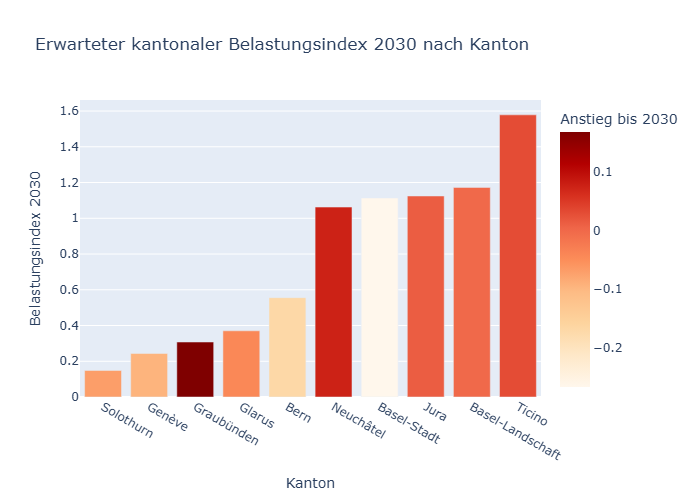

In [27]:
def project_linear(df: pd.DataFrame, value_col: str, target_year: int = 2030, min_points: int = 5) -> pd.DataFrame:
    rows = []
    for canton_code, group in df.groupby('canton_code'):
        g = group[['year', value_col]].dropna().sort_values('year')
        if len(g) < min_points:
            continue

        X = g[['year']].to_numpy(dtype=float)
        y = g[value_col].to_numpy(dtype=float)

        model = LinearRegression()
        model.fit(X, y)

        latest_observed_year = int(g['year'].max())
        latest_observed_value = float(g.loc[g['year'].idxmax(), value_col])
        projected_value = float(model.predict(np.array([[target_year]], dtype=float))[0])
        annual_slope = float(model.coef_[0])
        intercept = float(model.intercept_)
        r2 = float(model.score(X, y))

        rows.append({
            'canton_code': canton_code,
            f'{value_col}_latest': latest_observed_value,
            f'{value_col}_2030': projected_value,
            f'{value_col}_annual_slope': annual_slope,
            f'{value_col}_intercept': intercept,
            f'{value_col}_r2': r2,
            'latest_observed_year': latest_observed_year,
        })
    return pd.DataFrame(rows)

proj_cost = project_linear(analysis_panel, 'cost_per_capita')
proj_age = project_linear(analysis_panel, 'population_share_66_plus')
proj_premium = project_linear(analysis_panel, 'premium_median_monthly')

projection_2030 = (
    proj_cost
    .merge(proj_age.drop(columns=['latest_observed_year']), on='canton_code', how='inner')
    .merge(proj_premium.drop(columns=['latest_observed_year']), on='canton_code', how='inner')
)
projection_2030['canton_label'] = projection_2030['canton_code'].map(CODE_TO_LABEL)

for col in ['cost_per_capita_2030', 'population_share_66_plus_2030', 'premium_median_monthly_2030']:
    projection_2030[f'z_{col}'] = add_z_score(projection_2030[col])

projection_2030['belastungsindex_2030'] = (
    0.45 * projection_2030['z_cost_per_capita_2030']
    + 0.30 * projection_2030['z_population_share_66_plus_2030']
    + 0.25 * projection_2030['z_premium_median_monthly_2030']
)

latest_belastung = panel_latest[['canton_code', 'belastungsindex']].rename(columns={'belastungsindex': 'belastungsindex_latest'})
projection_2030 = projection_2030.merge(latest_belastung, on='canton_code', how='left')
projection_2030['delta_belastungsindex_to_2030'] = projection_2030['belastungsindex_2030'] - projection_2030['belastungsindex_latest']

display(
    projection_2030.sort_values('belastungsindex_2030', ascending=False)[[
        'canton_label', 'cost_per_capita_2030', 'population_share_66_plus_2030',
        'premium_median_monthly_2030', 'belastungsindex_2030', 'delta_belastungsindex_to_2030',
        'cost_per_capita_r2', 'population_share_66_plus_r2', 'premium_median_monthly_r2'
    ]].head(10)
)

fig = px.bar(
    projection_2030.sort_values('belastungsindex_2030').tail(10),
    x='canton_label',
    y='belastungsindex_2030',
    color='delta_belastungsindex_to_2030',
    title='Erwarteter kantonaler Belastungsindex 2030 nach Kanton',
    labels={'canton_label': 'Kanton', 'belastungsindex_2030': 'Belastungsindex 2030', 'delta_belastungsindex_to_2030': 'Anstieg bis 2030'},
    color_continuous_scale='OrRd',
)
fig.show()


## Management Summary

Die Ergebnisse lassen sich direkt entlang der vier Leitfragen verdichten und in Handlungsimpulse für das Management übersetzen.


In [28]:
manager_table = projection_2030.sort_values('belastungsindex_2030', ascending=False)[[
    'canton_code', 'canton_label', 'belastungsindex_latest', 'belastungsindex_2030', 'delta_belastungsindex_to_2030',
    'cost_per_capita_2030', 'population_share_66_plus_2030', 'premium_median_monthly_2030'
]].copy()

manager_table['priority_flag'] = np.where(
    (manager_table['belastungsindex_2030'] >= manager_table['belastungsindex_2030'].quantile(0.75))
    | (manager_table['delta_belastungsindex_to_2030'] >= manager_table['delta_belastungsindex_to_2030'].quantile(0.75)),
    'Prioritär beobachten',
    'Regulär beobachten',
)

display(manager_table.head(12))


,canton_code,canton_label,belastungsindex_latest,belastungsindex_2030,delta_belastungsindex_to_2030,cost_per_capita_2030,population_share_66_plus_2030,premium_median_monthly_2030,priority_flag
20,TI,Ticino,1.549,1.579,0.030,"14,730.582",0.244,697.683,Prioritär beobachten
4,BL,Basel-Landschaft,1.173,1.173,-0.000,"13,791.582",0.236,687.878,Prioritär beobachten
10,JU,Jura,1.111,1.125,0.013,"13,604.084",0.234,696.670,Prioritär beobachten
5,BS,Basel-Stadt,1.381,1.114,-0.267,"15,064.362",0.179,766.425,Prioritär beobachten
12,NE,Neuchâtel,0.988,1.063,0.075,"14,124.824",0.200,761.260,Prioritär beobachten
3,BE,Bern,0.726,0.556,-0.170,"12,777.271",0.226,623.608,Prioritär beobachten
8,GL,Glarus,0.413,0.370,-0.042,"12,983.261",0.221,561.086,Prioritär beobachten
9,GR,Graubünden,0.140,0.308,0.168,"11,874.364",0.245,553.091,Prioritär beobachten
7,GE,Genève,0.339,0.244,-0.096,"12,793.612",0.158,788.778,Regulär beobachten
17,SO,Solothurn,0.218,0.149,-0.070,"11,893.644",0.212,630.771,Regulär beobachten


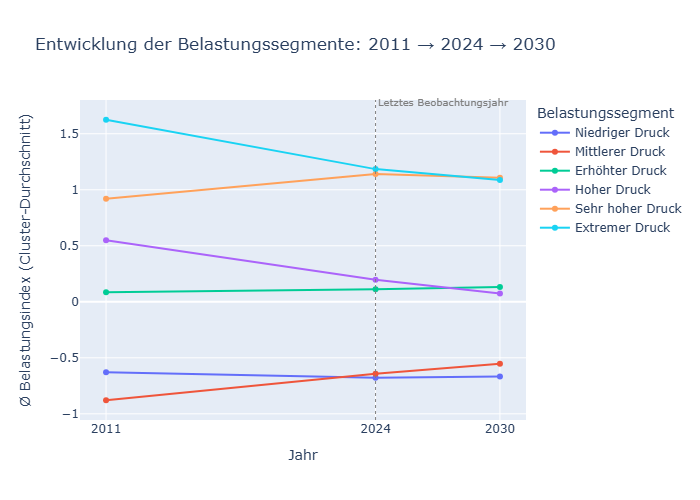

In [29]:
# Cluster-Entwicklung: Baseline → Latest → 2030
_cluster_map = cluster_frame[['canton_code', 'cluster_name']].copy()

_baseline = (
    analysis_panel[analysis_panel['year'] == baseline_year][['canton_code', 'belastungsindex']]
    .merge(_cluster_map, on='canton_code', how='inner')
    .groupby('cluster_name', as_index=False)['belastungsindex'].mean()
    .assign(jahr=baseline_year)
)

_latest = (
    cluster_frame[['canton_code', 'cluster_name', 'belastungsindex']]
    .groupby('cluster_name', as_index=False)['belastungsindex'].mean()
    .assign(jahr=latest_year)
)

_proj = (
    projection_2030[['canton_code', 'belastungsindex_2030']]
    .merge(_cluster_map, on='canton_code', how='inner')
    .groupby('cluster_name', as_index=False)['belastungsindex_2030'].mean()
    .rename(columns={'belastungsindex_2030': 'belastungsindex'})
    .assign(jahr=2030)
)

_cluster_trend = pd.concat([_baseline, _latest, _proj], ignore_index=True)

_cluster_order = [
    'Niedriger Druck', 'Mittlerer Druck', 'Erhöhter Druck',
    'Hoher Druck', 'Sehr hoher Druck', 'Extremer Druck',
]

fig = px.line(
    _cluster_trend,
    x='jahr',
    y='belastungsindex',
    color='cluster_name',
    markers=True,
    category_orders={'cluster_name': _cluster_order},
    title=f'Entwicklung der Belastungssegmente: {baseline_year} → {latest_year} → 2030',
    labels={
        'jahr': 'Jahr',
        'belastungsindex': 'Ø Belastungsindex (Cluster-Durchschnitt)',
        'cluster_name': 'Belastungssegment',
    },
)

fig.update_layout(
    xaxis=dict(tickvals=[baseline_year, latest_year, 2030]),
    shapes=[dict(
        type='line',
        x0=latest_year, x1=latest_year,
        y0=0, y1=1, yref='paper',
        line=dict(color='grey', width=1, dash='dot'),
    )],
    annotations=[dict(
        x=latest_year, y=1.02, yref='paper',
        text='Letztes Beobachtungsjahr', showarrow=False,
        xanchor='left', font=dict(size=10, color='grey'),
    )],
)
fig.show()

In [30]:

EXPORT_ANALYSIS_OUTPUTS = True

if EXPORT_ANALYSIS_OUTPUTS:
    analysis_panel.to_csv(PROCESSED_DIR / 'analysis_panel.csv', index=False)
    projection_2030.to_csv(PROCESSED_DIR / 'projection_2030.csv', index=False)
    manager_table.to_csv(PROCESSED_DIR / 'manager_priorities.csv', index=False)
    print('Exports geschrieben: analysis_panel.csv, projection_2030.csv, manager_priorities.csv')
else:
    print('Keine Exports geschrieben.')


Exports geschrieben: analysis_panel.csv, projection_2030.csv, manager_priorities.csv
